# Session 02 - Regression - Assignment
_______________
name: Carl Jonsson

In [6]:
%matplotlib inline
import numpy as np # numerical computations
import pandas as pd # data manipulations
import matplotlib.pyplot as plt # Plots
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import seaborn as sns; sns.set(color_codes=True) 

## 1. Wine quality

A lot of portugese Vinho Verde wines (http://www.vinhoverde.pt/en/) have been chemically analized. They have also been rated by a panel of wine experts. 

The features comprise:
1- fixed acidity | 2 - volatile acidity | 3 - citric acid | 4 - residual sugar | 5 - chlorides | 6 - free sulfur dioxide | 7 - total sulfur dioxide | 8 - density | 9 - pH | 10 - sulphates |11 - alcohol

The target variable is the quality score

Apply regression to (as accurately as possible) predict the quality score of the wine from the chemical parameters.


In [9]:
# Reading the dataset
dataset = pd.read_csv('winequality-red.csv',delimiter = ';') # pandas dataframe

dataset.shape

(1599, 12)

In [15]:
# Show first rows of the dataset
dataset.head(11)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### Statistical analysis

- Compute an overview of the main statistical parameters. Use the dataset.describe() function.
- Check for missing values
- Check for outliers
- Make a correlation heatmap and discuss the results
- Make a pairplot and discuss the results.


In [25]:
# Statistical description
dataset.describe()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [26]:
# Removing outliers
from scipy import stats
dataset = dataset[(np.abs(stats.zscore(dataset)) < 3).all(axis=1)]
dataset.describe()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000
mean,8.310062,0.522950,0.265382,2.387285,0.081425,15.104755,43.735355,0.996710,3.315934,0.642584,10.421089,5.659545
std,1.646458,0.168531,0.190934,0.862078,0.020966,9.309768,29.441284,0.001716,0.141096,0.129801,1.021588,0.781605
min,5.000000,0.120000,0.000000,1.200000,0.038000,1.000000,6.000000,0.991500,2.880000,0.330000,8.500000,4.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995600,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,36.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.630000,0.420000,2.600000,0.089000,21.000000,58.000000,0.997800,3.400000,0.720000,11.100000,6.000000
max,13.500000,1.040000,0.790000,6.700000,0.226000,47.000000,145.000000,1.002200,3.750000,1.160000,13.600000,8.000000


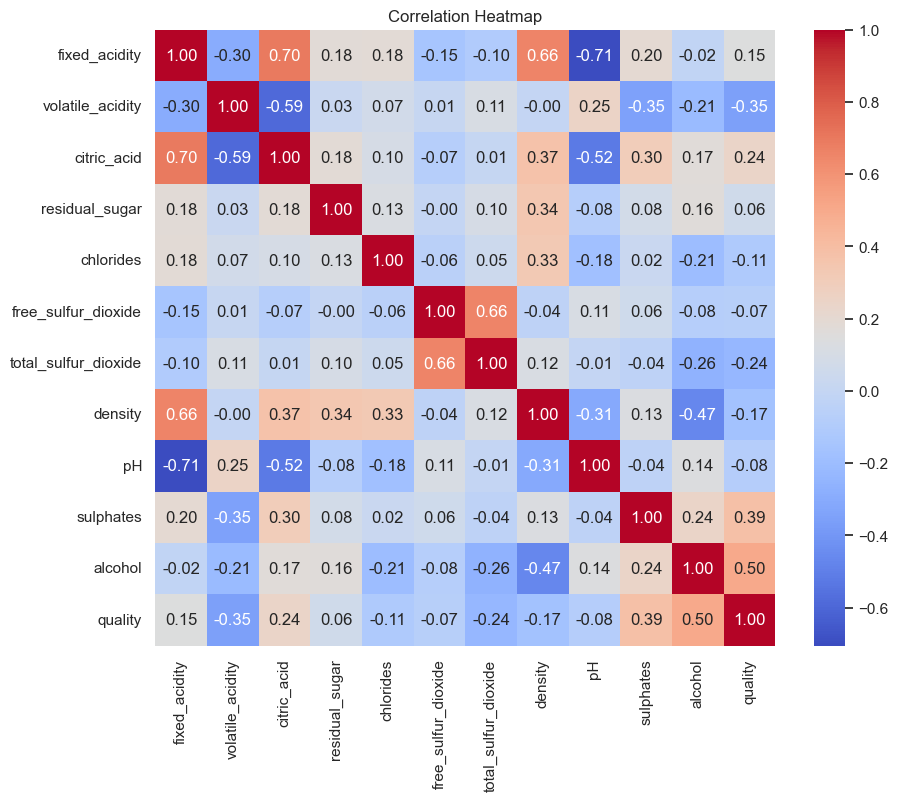

In [ ]:
# Correlation heatmap
corr = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# The result shows that the biggest correlation is between fixed_acidity, pH, and citric_acid.
# If the fixed_acidity increase by 1, pH will decrease with 0.71.
# And if fixed_acidity increase by 1, citric_acid will increase by 0.7.
# The heatmap also shows that the correlation between volatile_acidity and density is 0.
# The feature who has biggest correlation to quality is alcohol.

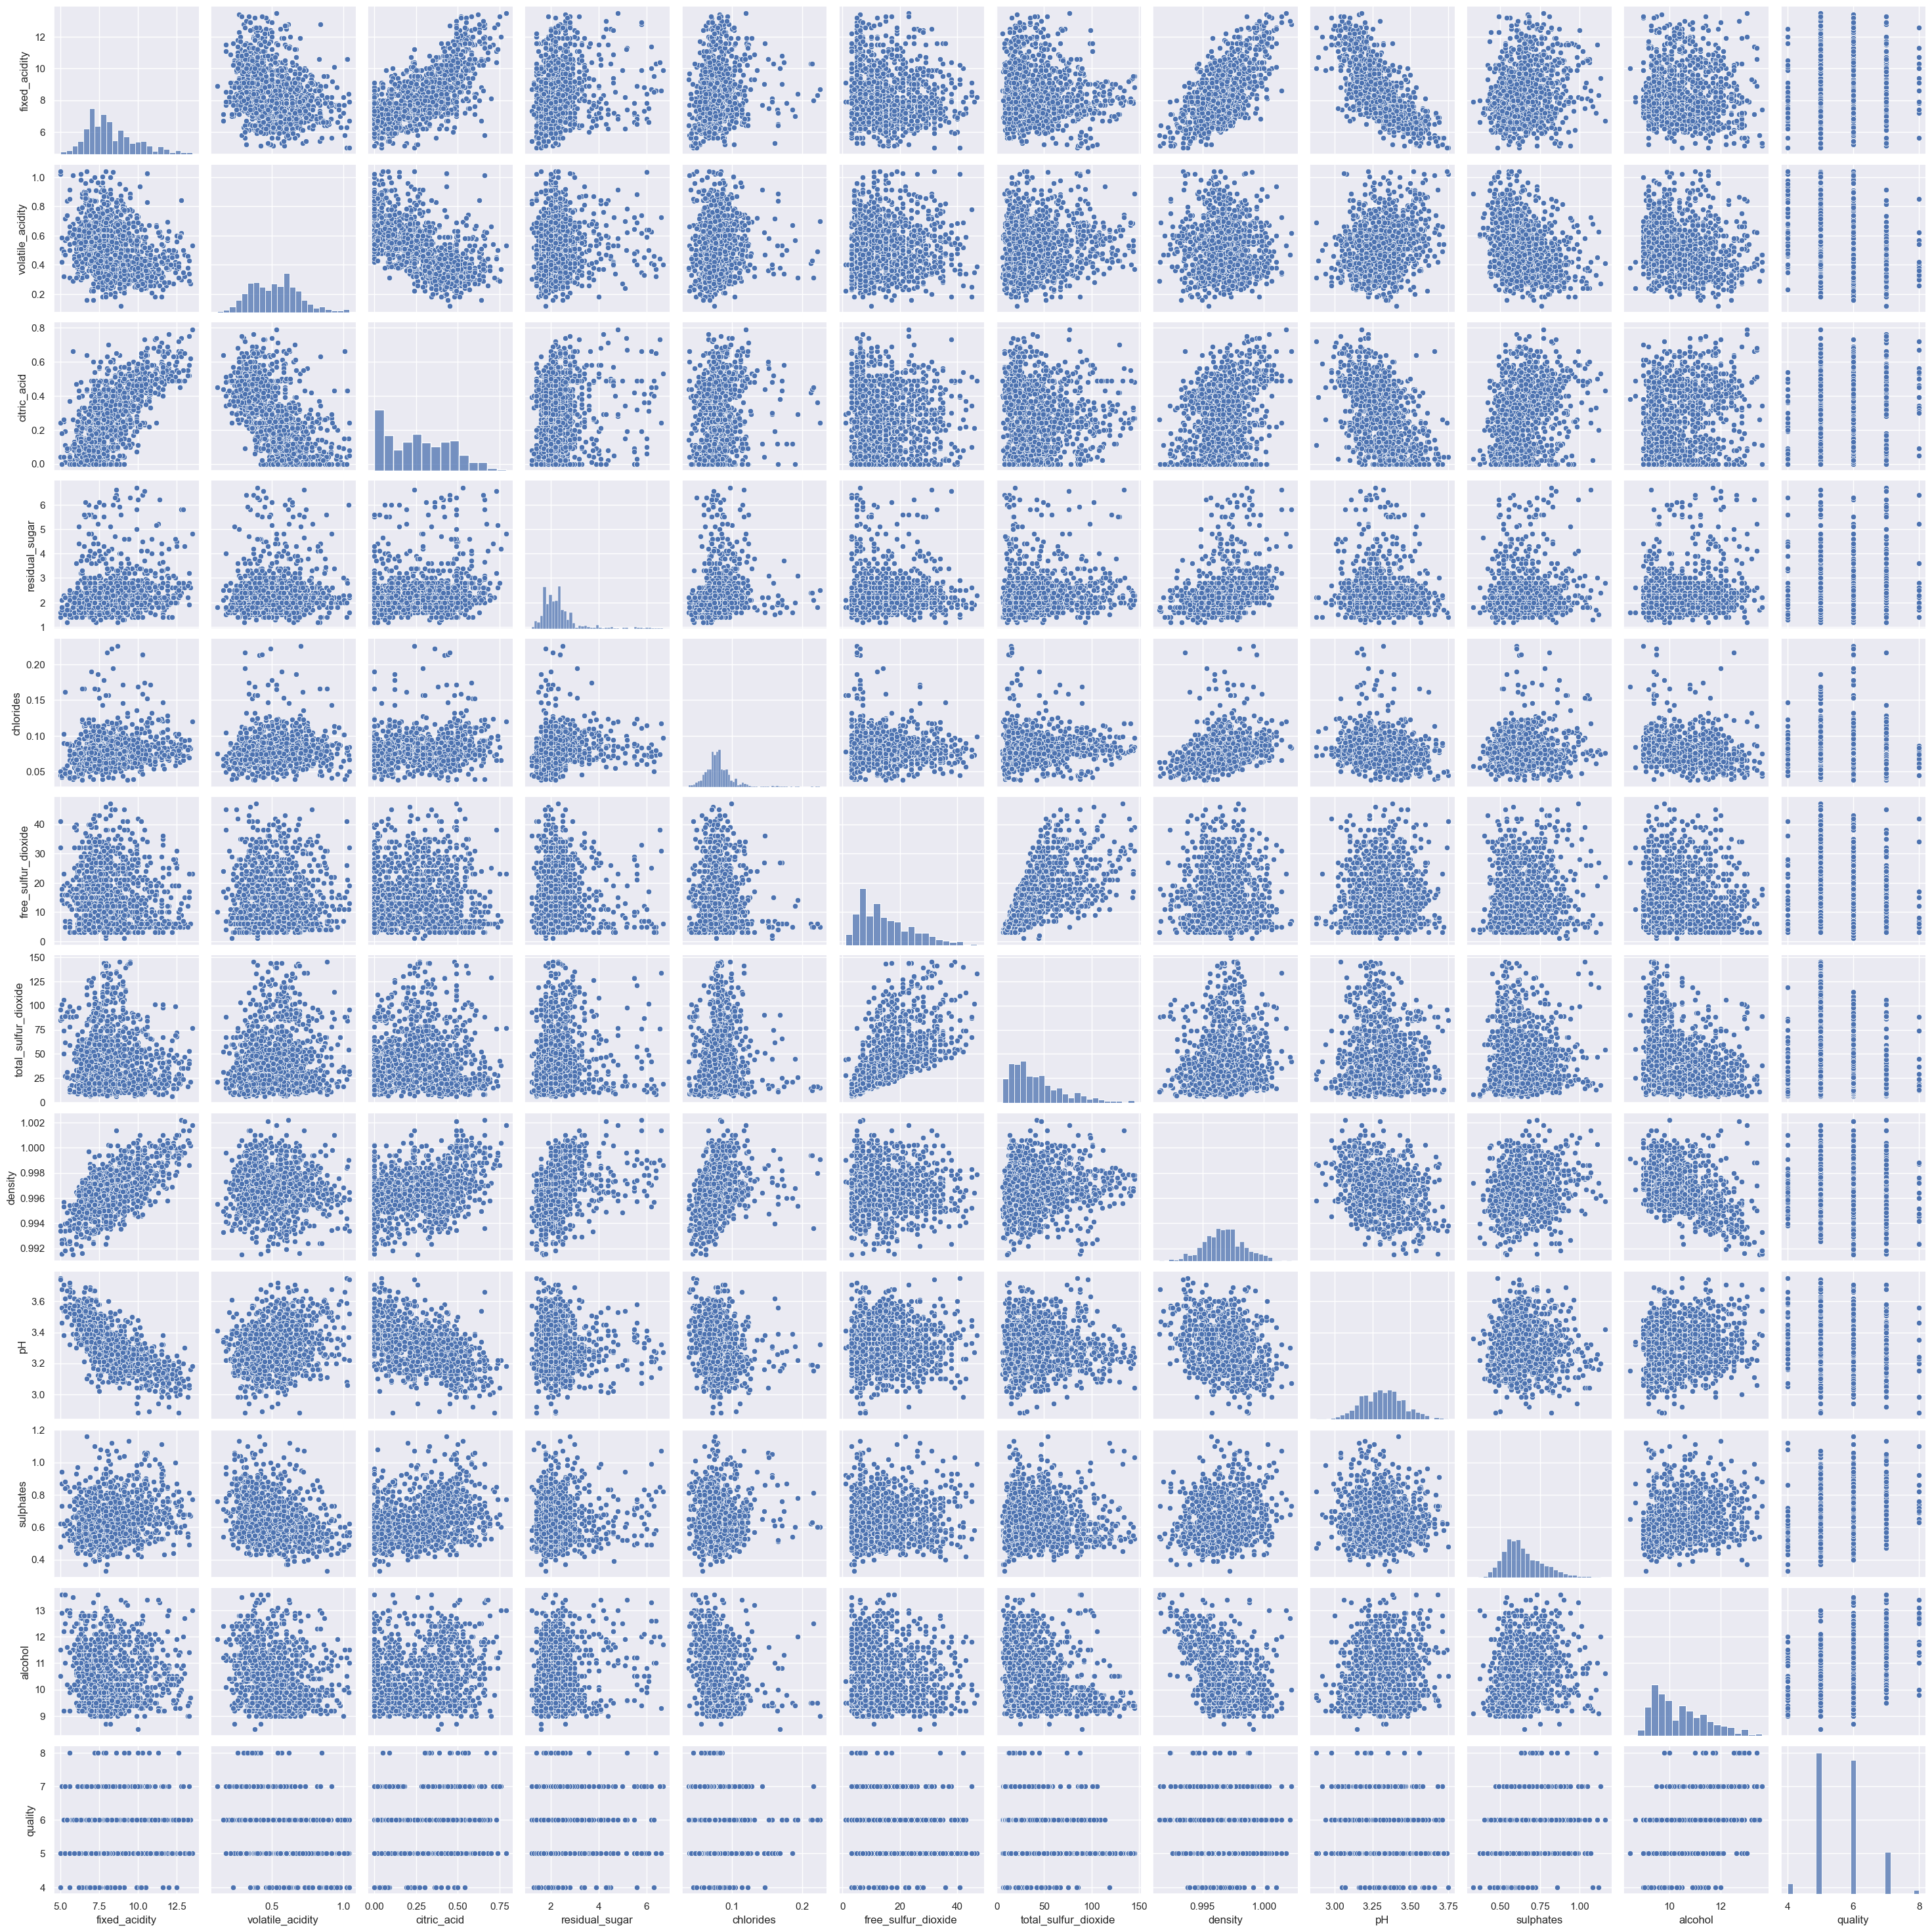

In [ ]:
# Pairplot
sns.pairplot(dataset)

# The result ...

### Splitting into training set and test set

In [5]:
# Split into features and targets.


In [3]:
# Split into training set and test set. Make sure that 30 percent
# of the wines end up in the test set.


(1119, 11)


In [18]:
# Scaling the training set and test set.







### Training the regression model

In [19]:
# Training of the regression model


LinearRegression()

In [2]:
# Print and interpret the coëfficiënts and intercept of the model


### Testing and predicting
Predict the wine quality of a wine with the following chemical parameters:

fixed_acidity: 7.3 | 
volatile_acidity: 0.70 | citric_acid: 0.00 | residual_sugar: 1.9 | chlorides: 0.079 | free_sulfur_dioxide: 11.0 | total_sulfur_dioxide: 34.0 | density: 0.9978 | pH: 3.51 | sulphates: 0.58 | alcohol: 9.4

In [3]:
# Prediction of the quality


Evaluate the model on the test set in terms of MAE, MSE and the $R^2$-score.

In [4]:
# Evaluate the model in terms of MAE, MSE and R2-score on the test set
# Evaluation of the model



### Model optimization

Try to improve the performance of the model. In other words, try to improve the $R^2$-score of the model.
Possible options to improve the model performance are:
-  Adding higher-order features.
-  Think of new features that can be added to the dataset or computed from the existing features.
- Use Ridge regression and Lasso regression. Try to find a good value for alpha, the regularization parameter.
- Check for underfitting and overfitting.
- You can add higher-order features by means of the sklearn.preprocessing.PolynomialFeatures function. Don't go higher than a fourth-order polynomial.

In [5]:
# Model optimization and hyperparameter tuning.

from sklearn.preprocessing import PolynomialFeatures


# higher order features

degree = 2



In [7]:
# R² as a function of alpha

train_r2 = []
test_r2 = []


alphas = np.linspace(0.0001, 200, 500)

for alpha in alphas:
    lregmodel_poly = Ridge(alpha=alpha,tol=0.0001,fit_intercept=True)
    lregmodel_poly.fit(X_train_poly,y_train)
    test_r2.append(lregmodel_poly.score(X_test_poly,y_test))  
    train_r2.append(lregmodel_poly.score(X_train_poly,y_train))


# Plot r2
f, ax = plt.subplots(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.semilogx(alphas, train_r2, label='Train')
plt.semilogx(alphas, test_r2, label='Test')
plt.legend(loc='lower left')
plt.ylim([0, 1.2])
plt.xlabel('Regularization parameter alpha')
plt.ylabel('R² Performance')



# 2. Parkinson

Tracking Parkinson's disease symptom progression often uses the unified Parkinson's disease rating scale (UPDRS). But the tracking has to happen in the hospital by trained staff, which is very time-consuming for the patient and the hospital staff. 

In 2010 a data set was published [1] that was composed of a range of biomedical voice measurements from 42 people with early-stage Parkinson's disease recruited to a six-month trial of a telemonitoring device for remote symptom progression monitoring. The recordings were automatically captured in the patient's homes. 


> [1] A. Tsanas, M. A. Little, P. E. McSharry, L. O. Ramig (2010),
*Accurate telemonitoring of Parkinson's disease progression by non-invasive 
speech tests*,
IEEE Transactions on Biomedical Engineering;57(4):884-93.

Here you can find a overview of the features: 

|      feature      | Description | 
|------------|-----|
| age | Subject age. |
| sex | Subject gender '0' - male, '1' - female.|
| test_time | Time since recruitment into the trial. The integer part is the number of days since recruitment. |
| Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP | Several measures of variation in fundamental frequency. |
| Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA | Several measures of variation in amplitude. |
| NHR,HNR | Two measures of the ratio of noise to tonal components in the voice. |
| RPDE | A nonlinear dynamical complexity measure. |
| DFA | Signal fractal scaling exponent. |
| PPE | A nonlinear measure of fundamental frequency variation. |
| motor_UPDRS | Clinician's motor Unified Parkinson's Disease Rating Scale (UPDRS) score, linearly interpolated. (target)|

The goal is to use multiple linear regression to predict the motor_UPDRS as reliably as possible.

### Reading the dataset

In [10]:
# Read the dataset

dataset = pd.read_csv("parkinsons_updrs.csv")
dataset.head()

,age,sex,test_time,motor_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,72,0,5.6431,28.199,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,72,0,12.6660,28.447,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,72,0,19.6810,28.695,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,72,0,25.6470,28.905,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,72,0,33.6420,29.187,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


What's the shape of the dataset?

In [ ]:
# shape of the dataset


### Statistical pre-analysis

- Provide a summary table with the describe function of pandas.
- Check whether the dataset contains missing values. If it does, delete the rows with missing values.
- Is there any outlier data at first glance? Although this is not completely true for multidimensional correlated data, in this task you can consider outliers as feature values that are more than 5 standard deviations from the mean.
- Create a heatmap. Which features seem to have the most influence on the motor_UDPS? Are there features that are strongly correlated with each other? If you were to omit 3 features, which would they be? Explain why. With this question, the explanation is important.
- Make a pairplot, look at it carefully and formulate some conclusions. Are there any connections between what you see on the pairplot and on the correlation heatmap?



In [12]:
# Statistical pre-analysis


### Splitting up the dataset

Split the dataset into features X and targets y. Then you can split the dataset into a training set and a test set. Use the function train_test_split from Sklearn (http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Make sure that 20 percent of the dataset ends up in the test set.

Visualise your features with a boxplot, are there any features present that are on a completly different scale, does this dataset need to be normalised?
Scale/normalise the training set and the test set with a standards scaler. Try later also with a robustscaler.
Explain what the difference is between the standardscaler and the robustscaler.
The labels do not need to be scaled or normalized.

In [13]:
# splitting into target and features


In [14]:
# Visualise your features with a boxplot


In [15]:
# Splitting the dataset into a train- and testset


In [16]:
# Scaling the data


## Training the regression model

Train a regression model via linear_model.LinearRegression(). Then print and interpret the model coefficients. 

In [17]:
# Training the regression model


In [18]:
# print the coefficients and the intercept of the model


### Model optimization
Try to improve the performance of the model. In other words, lower the MAE and the MSE and increase the $R^2$ score.
Possible options are:
- Adding higher order features (manually). Justify why you would use certain higher order features. Look for example at the pairplot or the correlation heatmap (look for non-linearities).
- Derive additional features from existing features.
- Apply regularisation via Ridge regression and Lasso regression. Always look for a good value for alpha. 
- Always check if there is overfitting or underfitting. Do this by comparing the performance on the training set with the performance on the test set. 
- Add higher order features automatically via sklearn.preprocessing.PolynomialFeatures. Do not go higher than 3rd order. The number of features increases exponentially with the order, with the result that the model can no longer be trained within an acceptable time.

Always motivate the made decisions and evaluate the model with the test set. What is the best performance you can achieve? **Discuss the final result**.

In [19]:
# Model optimization

# 3. Car prices


In this exercise, you will work on a machine learning problem in which you will predict the price of used cars. The dataset provided contains information about different car listings including features such as make, model, year, power, fuel type, transmission type, age, mileage. You will apply regression techniques to build a predictive model capable of estimating the price of the cars as accurately as possible.

## 3.1. Data analysis


Load the dataset and perform exploratory data analysis (EDA) to understand its structure, feature distributions, missing values, and correlations.
Visualize relationships between features and the target variable (car price) using scatter plots, histograms, boxplots and correlation matrices.

For example:

- Number of samples
- Check for missing values
- Check for (extreme) outlier
- Histrogram of the car prices
- Distribution of the car brands
- Distribution of the fuel consumption
- Scatterplot of the price and the fuel consumption
- Distribution of the mileage
- Scatterplot of the price and the milage
- Boxplot of the price per brand
- Boxplot of the price per color
- Scatterplot of the price and age
- Boxplot of the price per transmission_type
- Correlation heatmap


**Write down some conclusions:**
- What is number of missing values? Is this problematic? Which strategy will you choose to deal with these missing values? Impute missing values of listwise deletion.
- Are there any redundant variables?
- What are the important features?


## 3.2. Data preprocessing
- Remove the offer_description feature from the dataset
- Handle missing values appropriately (e.g., imputation, removal).
- Encode categorical variables if necessary (e.g., one-hot encoding).
- Scale numerical features to ensure they are on a similar scale.

## 3.3. Feature engineering

- Extract relevant features from existing ones if necessary (if applicable).
- Create new features that might enhance prediction (e.g., calculate car age from year of manufacture).

## 3.4. Model building

- Split the dataset into features and targets
- Split the dataset into training and testing sets.
- Choose appropriate regression algorithms (e.g., Linear Regression, Ridge Regression, Lasso Regression).
- Train multiple regression models using the training data.
- Evaluate the models using appropriate evaluation metrics (e.g., Mean Squared Error, R-squared).

## 3.5. Model Optimization:
- Fine-tune hyperparameters of the models

## 3.6. Model Evaluation:
- Compare the performance of different models based on evaluation metrics.
- Select the best-performing model for further analysis.


## 3.7. Prediction:
- Go to a second-hand car website and choose a car. Predict the price of that car and compare it to the announced price on the website.

## 3.8. Conclusion:
Summarize findings and discuss the effectiveness of the predictive model.





In [8]:
dataset = pd.read_csv('carprices.csv')
dataset.head()

,brand,model,color,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,mileage_in_km,offer_description
0,alfa-romeo,Alfa Romeo GTV,red,1995,1300,148.0,201.0,Manual,Petrol,10.9,160500.0,2.0 V6 TB
1,alfa-romeo,Alfa Romeo 164,black,1995,24900,191.0,260.0,Manual,Petrol,NaN,190000.0,"Q4 Allrad, 3.2L GTA"
2,alfa-romeo,Alfa Romeo Spider,black,1995,5900,110.0,150.0,Unknown,Petrol,NaN,129000.0,ALFA ROME 916
3,alfa-romeo,Alfa Romeo Spider,black,1995,4900,110.0,150.0,Manual,Petrol,9.5,189500.0,2.0 16V Twin Spark L
4,alfa-romeo,Alfa Romeo 164,red,1996,17950,132.0,179.0,Manual,Petrol,7.2,96127.0,"3.0i Super V6, absoluter Topzustand !"


In [10]:
# Solution
dataset.shape

(249173, 12)